In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

In [10]:
df = pd.read_csv('C:/Users/joshd/Documents/ML Project Sem-7/merged_sales_data.csv')

In [11]:
# Features & Target
X = df[['Sales_2023', 'Sales_2024', 'Sales_2025', 'Growth_2024', 'Growth_2025', 'Sales_Variability']]
y = df['Total_Sales'] * 1.2  # Assume next year ~20% growth on total sales as CLV (or actual data if available)

In [12]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

In [13]:
# Evaluate
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

RMSE: 1091641.6112419865
R2 Score: 0.961456392005069


In [14]:
import matplotlib.pyplot as plt

In [16]:
# Example: If you have your trained model as `model`
df['Predicted_CLV'] = model.predict(df[['Sales_2023', 'Sales_2024', 'Sales_2025', 'Growth_2024', 'Growth_2025', 'Sales_Variability']])

# Sort by Predicted CLV
df = df.sort_values(by='Predicted_CLV', ascending=False)

In [17]:
# Define percentiles for segmentation
df['CLV_Segment'] = pd.qcut(df['Predicted_CLV'], q=[0, 0.4, 0.7, 0.9, 1.0],
                             labels=['Bronze', 'Silver', 'Gold', 'Platinum'])

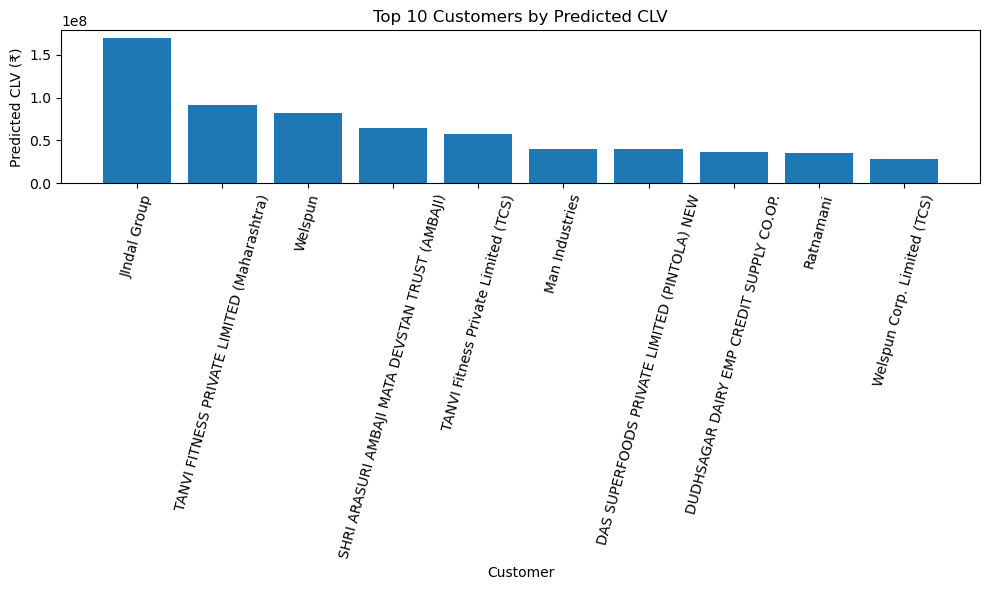

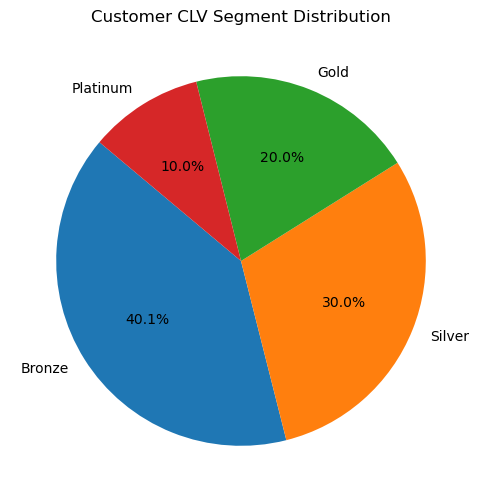

In [18]:
# ✅ Bar Chart for Top 10 Customers by CLV
top_10 = df.head(10)
plt.figure(figsize=(10, 6))
plt.bar(top_10['Customer_Name'], top_10['Predicted_CLV'])
plt.xticks(rotation=75)
plt.title('Top 10 Customers by Predicted CLV')
plt.xlabel('Customer')
plt.ylabel('Predicted CLV (₹)')
plt.tight_layout()
plt.savefig('top_10_clv_customers.png')
plt.show()

# ✅ Pie Chart for CLV Segment Distribution
segment_counts = df['CLV_Segment'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Customer CLV Segment Distribution')
plt.savefig('clv_segment_distribution.png')
plt.show()

In [19]:
# ✅ Save CLV Segmentation Report
df.to_csv('C:/Users/joshd/Documents/ML Project Sem-7/clv_segmentation_report.csv', index=False)
print("✅ CLV segmentation completed and saved as clv_segmentation_report.csv")

✅ CLV segmentation completed and saved as clv_segmentation_report.csv
